# Import libraries

In [1]:
# %% Setup
from __future__ import annotations

import os
import sys
import warnings
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

try:
    import plotly.express as px
    import plotly.graph_objects as go
    import plotly.io as pio
    from plotly.subplots import make_subplots
except ImportError as exc:
    raise ImportError(
        "Plotly is required for this EDA notebook. Install with: pip install plotly"
    ) from exc

# Display / warnings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
warnings.filterwarnings("ignore")

# Seaborn / matplotlib theme
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update(
    {
        "figure.figsize": (12, 5),
        "figure.dpi": 120,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
    }
)

# Plotly theme
pio.templates.default = "plotly_white"
_preferred_renderer = "vscode" if os.environ.get("VSCODE_PID") else "notebook_connected"
if _preferred_renderer in pio.renderers:
    pio.renderers.default = _preferred_renderer


def find_project_root(start: Path) -> Path:
    """Find project root by locating `data/raw` or `src`."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw").exists():
            return candidate
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data" / "raw"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"DATA_DIR      = {DATA_DIR}")

PROJECT_ROOT = /home/dxk/Data/Repos/DATATHON-2026-VinUni
DATA_DIR      = /home/dxk/Data/Repos/DATATHON-2026-VinUni/data/raw


# Load data

In [2]:
# %% Load Data
from __future__ import annotations

TABLE_FILES: Dict[str, str] = {
    "products": "products.csv",
    "customers": "customers.csv",
    "geography": "geography.csv",
    "promotions": "promotions.csv",
    "orders": "orders.csv",
    "order_items": "order_items.csv",
    "returns": "returns.csv",
    "payments": "payments.csv",
    "web_traffic": "web_traffic.csv",
    "inventory": "inventory.csv",
    "reviews": "reviews.csv",
    "sales": "sales.csv",
    "shipments": "shipments.csv",
}

TABLE_DATE_COLUMNS: Dict[str, Sequence[str]] = {
    "customers": ["signup_date"],
    "inventory": ["snapshot_date"],
    "orders": ["order_date"],
    "promotions": ["start_date", "end_date"],
    "returns": ["return_date"],
    "reviews": ["review_date"],
    "sales": ["Date"],
    "shipments": ["ship_date", "delivery_date"],
    "web_traffic": ["date"],
}

try:
    from src.data.load_data import load_table as _repo_load_table
except Exception:
    _repo_load_table = None


def _coerce_date_columns(df: pd.DataFrame, cols: Sequence[str]) -> pd.DataFrame:
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df


def load_csv_safe(file_path: Path, date_cols: Sequence[str] = ()) -> Optional[pd.DataFrame]:
    """Load a CSV if it exists; otherwise return None."""
    if not file_path.exists():
        print(f"[skip] Missing file: {file_path.name}")
        return None
    df = pd.read_csv(file_path)
    df = _coerce_date_columns(df, date_cols)
    return df


def load_table_safe(table: str) -> Optional[pd.DataFrame]:
    """Load by logical table name with graceful fallback."""
    if table not in TABLE_FILES:
        raise KeyError(f"Unknown table: {table}")

    date_cols = TABLE_DATE_COLUMNS.get(table, ())
    file_path = DATA_DIR / TABLE_FILES[table]

    # Preferred path: reuse repo loader (includes parse_dates)
    if _repo_load_table is not None:
        try:
            df = _repo_load_table(table, raw_dir=DATA_DIR)
            df = _coerce_date_columns(df, date_cols)
            return df
        except FileNotFoundError:
            print(f"[skip] Missing file: {file_path.name}")
            return None
        except Exception as exc:
            print(f"[warn] Repo loader failed for {table}: {exc}. Falling back to pd.read_csv().")

    # Fallback path
    df = load_csv_safe(file_path, date_cols=date_cols)
    if df is None:
        return None

    # Standardize common date column casing issues
    if table == "sales" and "Date" not in df.columns and "date" in df.columns:
        df = df.rename(columns={"date": "Date"})
        df = _coerce_date_columns(df, ["Date"])
    return df


dfs: Dict[str, pd.DataFrame] = {}
for name in TABLE_FILES:
    df = load_table_safe(name)
    if df is not None:
        dfs[name] = df

# Notebook-friendly globals (each table becomes a variable)
for name in TABLE_FILES:
    globals()[name] = dfs.get(name)

print("Loaded tables:")
for name, df in dfs.items():
    print(f"- {name:12s} {df.shape}")

Loaded tables:
- products     (2412, 8)
- customers    (121930, 7)
- geography    (39948, 4)
- promotions   (50, 10)
- orders       (646945, 8)
- order_items  (714669, 7)
- returns      (39939, 7)
- payments     (646945, 4)
- web_traffic  (3652, 7)
- inventory    (60247, 17)
- reviews      (113551, 7)
- sales        (3833, 3)
- shipments    (566067, 4)


# Data Overview

In [3]:
# %% Data Overview
def _dtype_compact(df: pd.DataFrame) -> str:
    kinds = df.dtypes.apply(lambda x: x.kind).value_counts()
    mapping = {
        "i": "int",
        "u": "uint",
        "f": "float",
        "b": "bool",
        "M": "datetime",
        "O": "object",
    }
    parts: List[str] = []
    for kind, count in kinds.items():
        label = mapping.get(kind, str(kind))
        parts.append(f"{label}:{int(count)}")
    return ", ".join(parts)


def summarize_tables(tables: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows: List[Dict[str, Any]] = []
    for name, df in tables.items():
        n_rows, n_cols = df.shape
        total_cells = max(n_rows * n_cols, 1)
        missing_pct = 100.0 * float(df.isna().sum().sum()) / total_cells
        dup_rows = int(df.duplicated().sum()) if n_rows else 0
        memory_mb = float(df.memory_usage(deep=True).sum()) / (1024.0**2)
        rows.append(
            {
                "table": name,
                "rows": n_rows,
                "cols": n_cols,
                "missing_%": missing_pct,
                "dup_rows": dup_rows,
                "memory_mb": memory_mb,
                "dtypes": _dtype_compact(df),
            }
        )
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    return out.sort_values(["rows", "cols"], ascending=False).reset_index(drop=True)


summary = summarize_tables(dfs)
display(summary)

# Column-level missingness (top 10 per table)
for name, df in dfs.items():
    miss = df.isna().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    if miss.empty:
        continue
    print(f"\nTop missing columns — {name}")
    display((100.0 * miss.head(10)).to_frame("missing_%"))

,table,rows,cols,missing_%,dup_rows,memory_mb,dtypes
0,order_items,714669,7,23.04,0,80.11,"int:3, float:2, object:2"
1,orders,646945,8,0.00,0,182.52,"object:4, int:3, datetime:1"
2,payments,646945,4,0.00,0,55.50,"int:2, object:1, float:1"
3,shipments,566067,4,0.00,0,17.28,"datetime:2, int:1, float:1"
4,customers,121930,7,0.00,0,32.77,"object:4, int:2, datetime:1"
5,reviews,113551,7,0.00,0,19.49,"int:4, object:2, datetime:1"
6,inventory,60247,17,0.00,0,18.14,"int:10, float:3, object:3, datetime:1"
7,geography,39948,4,0.00,0,7.78,"object:3, int:1"
8,returns,39939,7,0.00,0,6.68,"int:3, object:2, datetime:1, float:1"
9,sales,3833,3,0.00,0,0.09,"float:2, datetime:1"



Top missing columns — promotions


,missing_%
applicable_category,80.00



Top missing columns — order_items


,missing_%
promo_id_2,99.97
promo_id,61.34


# Helper Functions

In [4]:
# %% Helper Functions
from __future__ import annotations


def col_exists(df: Optional[pd.DataFrame], col: str) -> bool:
    return df is not None and col in df.columns


def pick_first_existing(df: pd.DataFrame, candidates: Sequence[str]) -> Optional[str]:
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand in df.columns:
            return cand
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None


def ensure_datetime(df: pd.DataFrame, candidates: Sequence[str]) -> Tuple[pd.DataFrame, Optional[str]]:
    """Return (df, chosen_date_col) where chosen_date_col is coerced to datetime."""
    date_col = pick_first_existing(df, candidates)
    if date_col is None:
        return df, None
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    return df, date_col


def safe_merge(
    left: pd.DataFrame,
    right: Optional[pd.DataFrame],
    *,
    on: Sequence[str] | str,
    how: str = "left",
    suffixes: Tuple[str, str] = ("", "_r"),
    validate: Optional[str] = None,
) -> pd.DataFrame:
    if right is None:
        return left
    on_cols = [on] if isinstance(on, str) else list(on)
    if any(c not in left.columns for c in on_cols) or any(c not in right.columns for c in on_cols):
        return left
    try:
        return left.merge(right, on=on_cols, how=how, suffixes=suffixes, validate=validate)
    except Exception:
        return left.merge(right, on=on_cols, how=how, suffixes=suffixes)


def infer_numeric_cols(df: pd.DataFrame) -> List[str]:
    cols = df.select_dtypes(include=["number"]).columns.tolist()
    return [c for c in cols if df[c].nunique(dropna=True) > 1]


def infer_categorical_cols(df: pd.DataFrame, max_unique_ratio: float = 0.05) -> List[str]:
    cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    # Treat low-cardinality ints as categorical
    for c in df.select_dtypes(include=["int", "int64", "uint", "uint64"]).columns:
        nunique = df[c].nunique(dropna=True)
        if nunique <= 30 or nunique / max(len(df), 1) <= max_unique_ratio:
            if c not in cat_cols:
                cat_cols.append(c)
    return cat_cols


def add_regression_line(fig: go.Figure, x: np.ndarray, y: np.ndarray, name: str = "Trend") -> go.Figure:
    mask = np.isfinite(x) & np.isfinite(y)
    x2, y2 = x[mask], y[mask]
    if x2.size < 3:
        return fig
    slope, intercept = np.polyfit(x2, y2, deg=1)
    x_line = np.linspace(x2.min(), x2.max(), 50)
    y_line = slope * x_line + intercept
    fig.add_trace(go.Scatter(x=x_line, y=y_line, mode="lines", name=name, line=dict(width=3, dash="dot")))
    return fig

# Univariate Analysis


=== Univariate: orders (n=200,000, p=8) ===


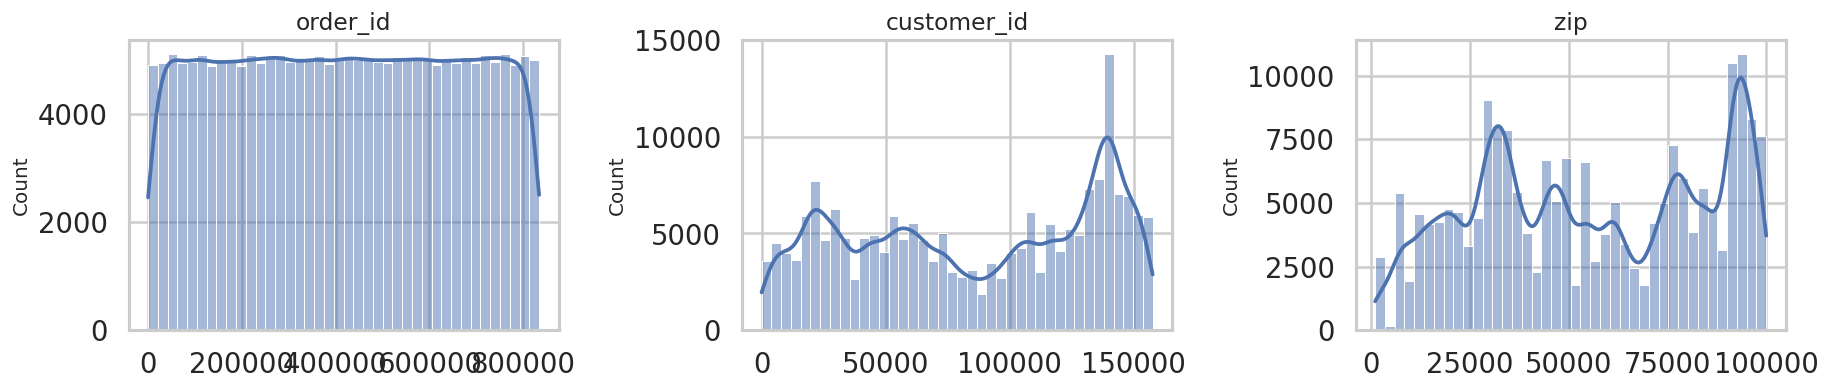

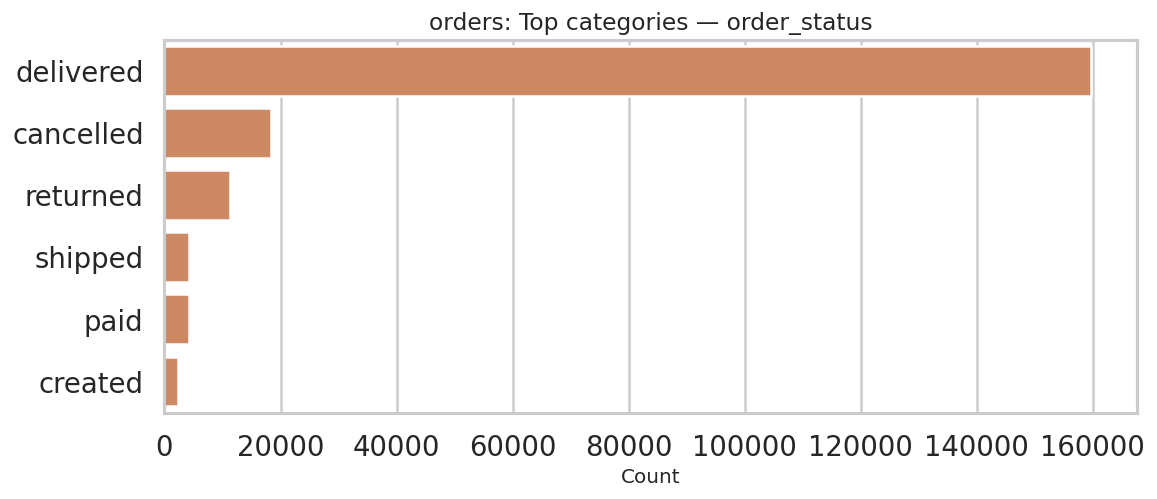

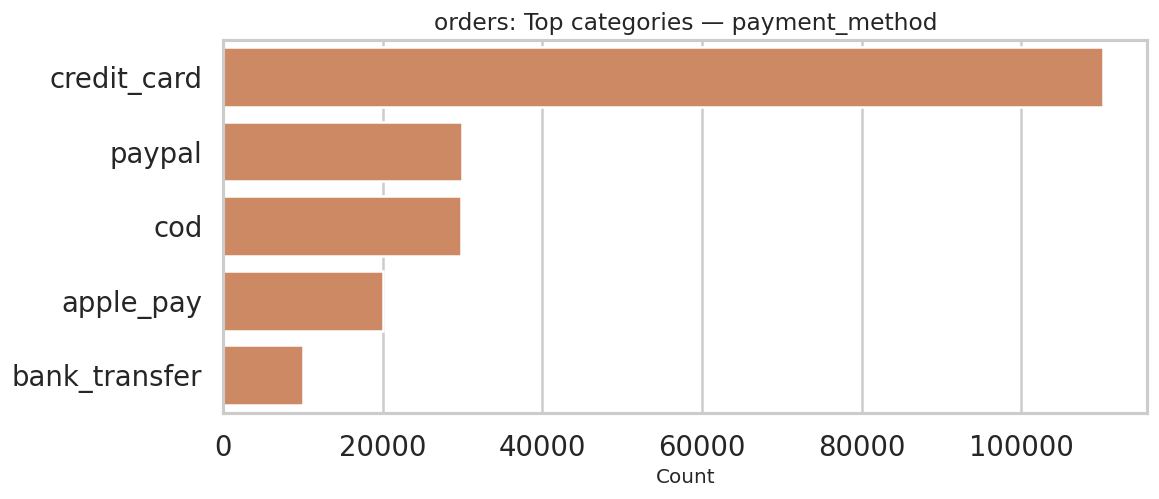

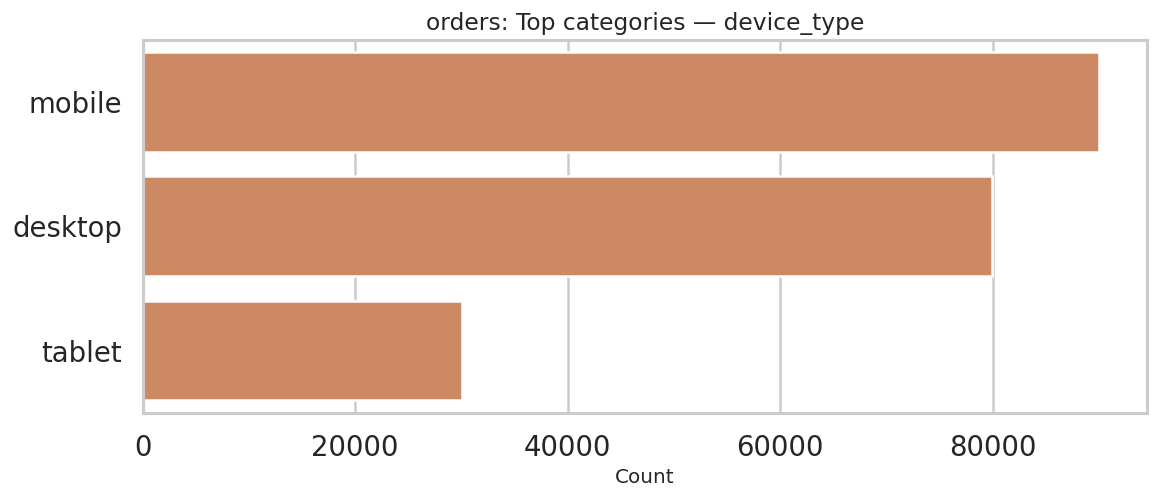

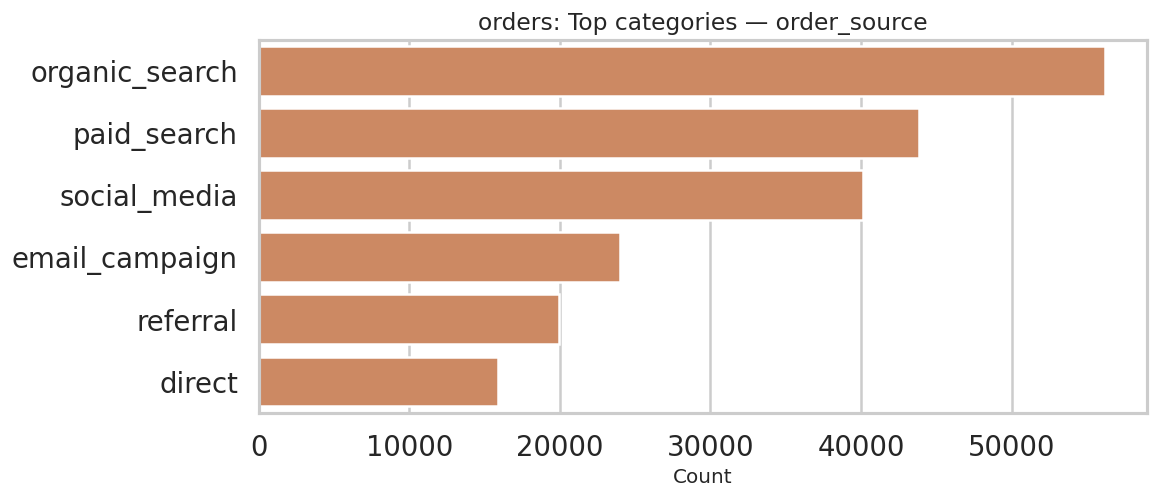


=== Univariate: sales (n=3,833, p=3) ===


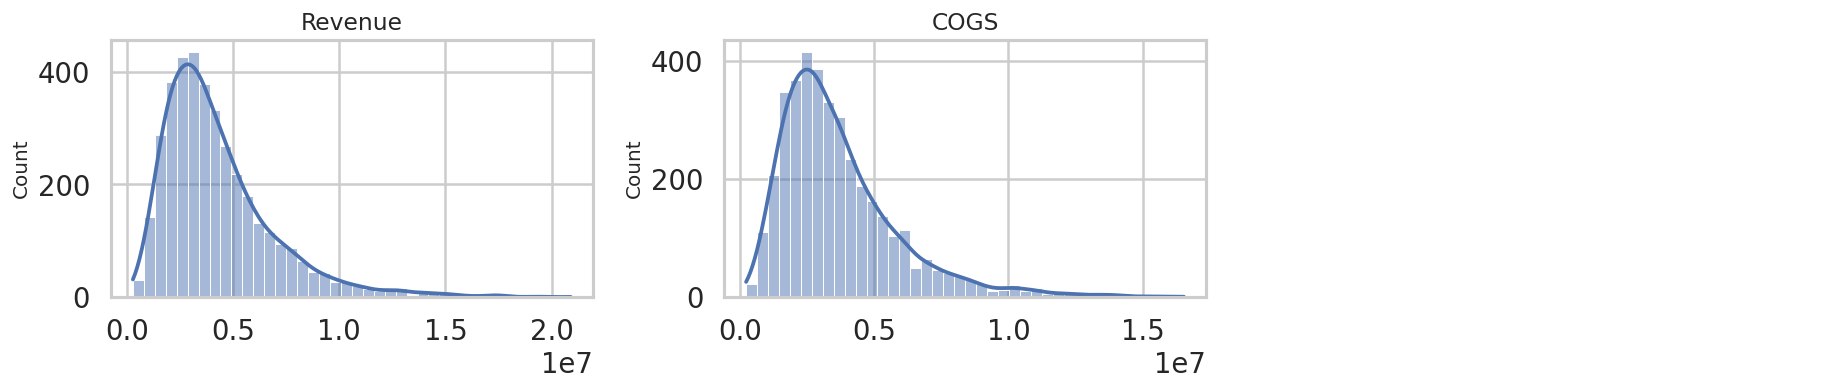

No categorical columns detected (or all high-cardinality).

=== Univariate: customers (n=121,930, p=7) ===


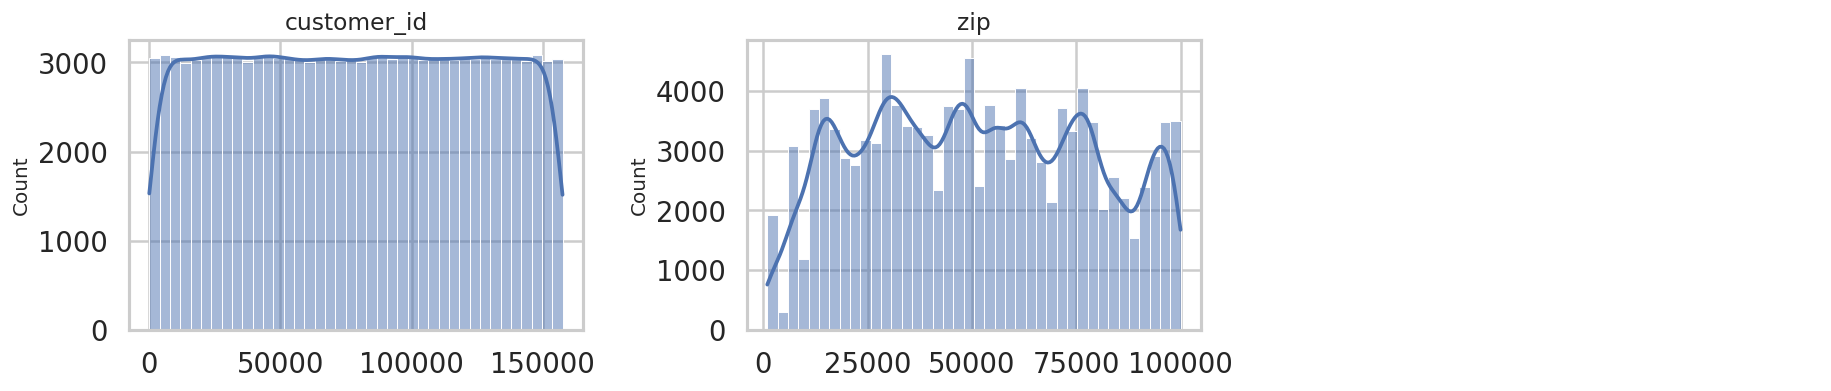

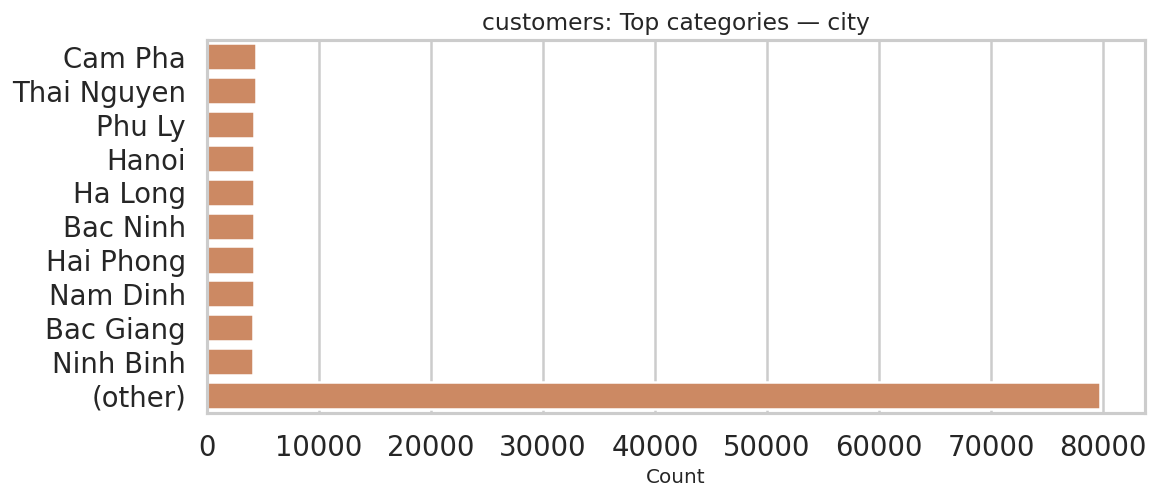

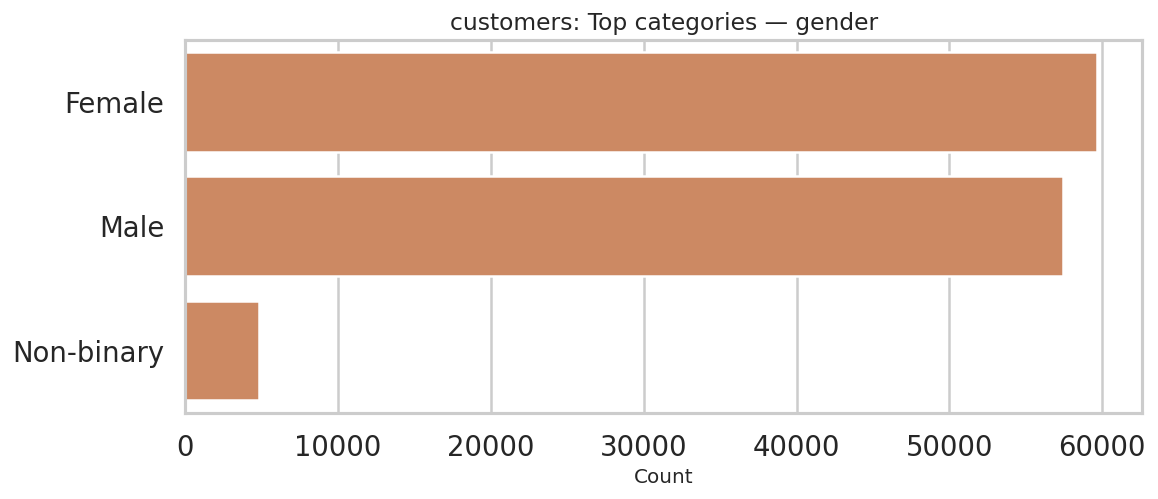

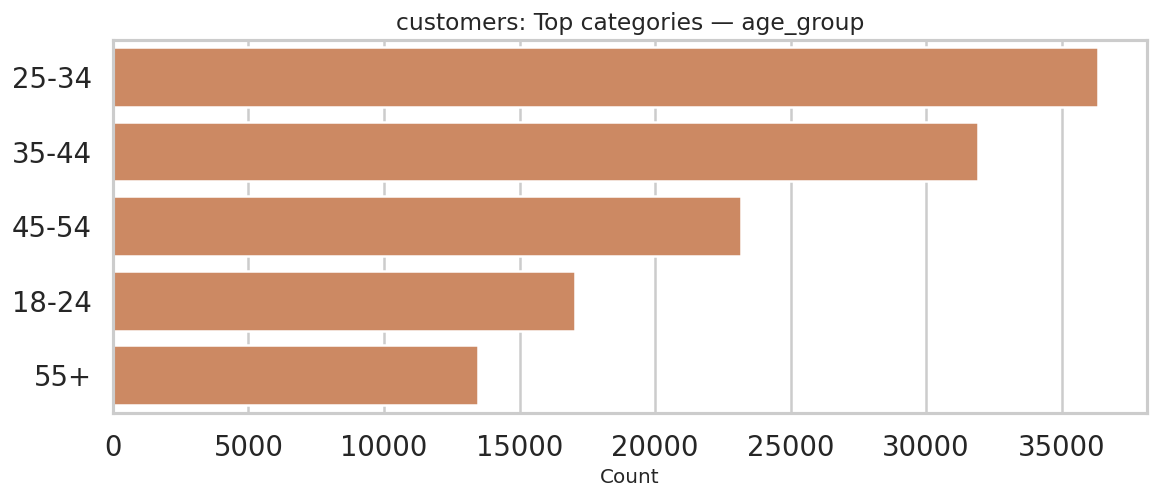

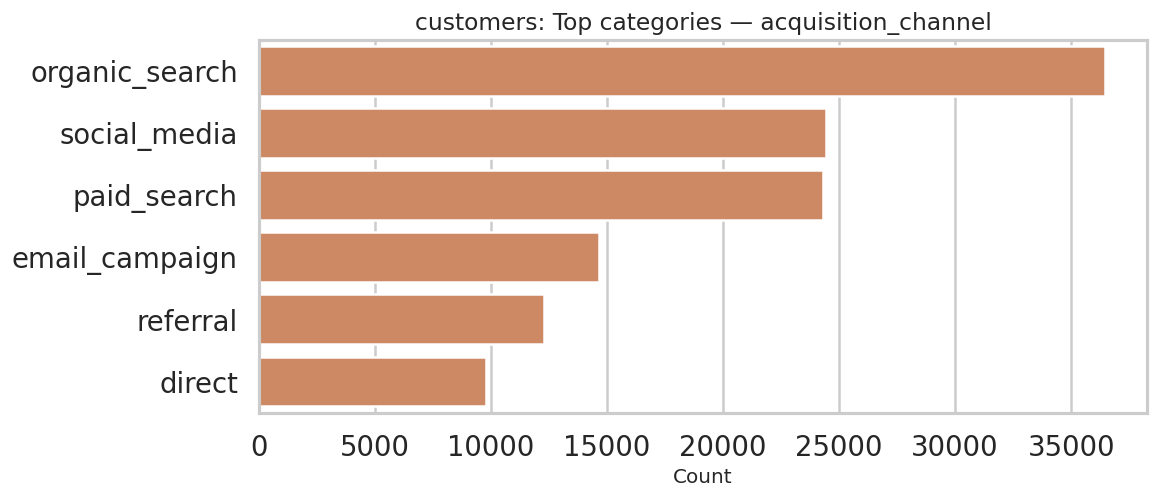


=== Univariate: reviews (n=113,551, p=7) ===


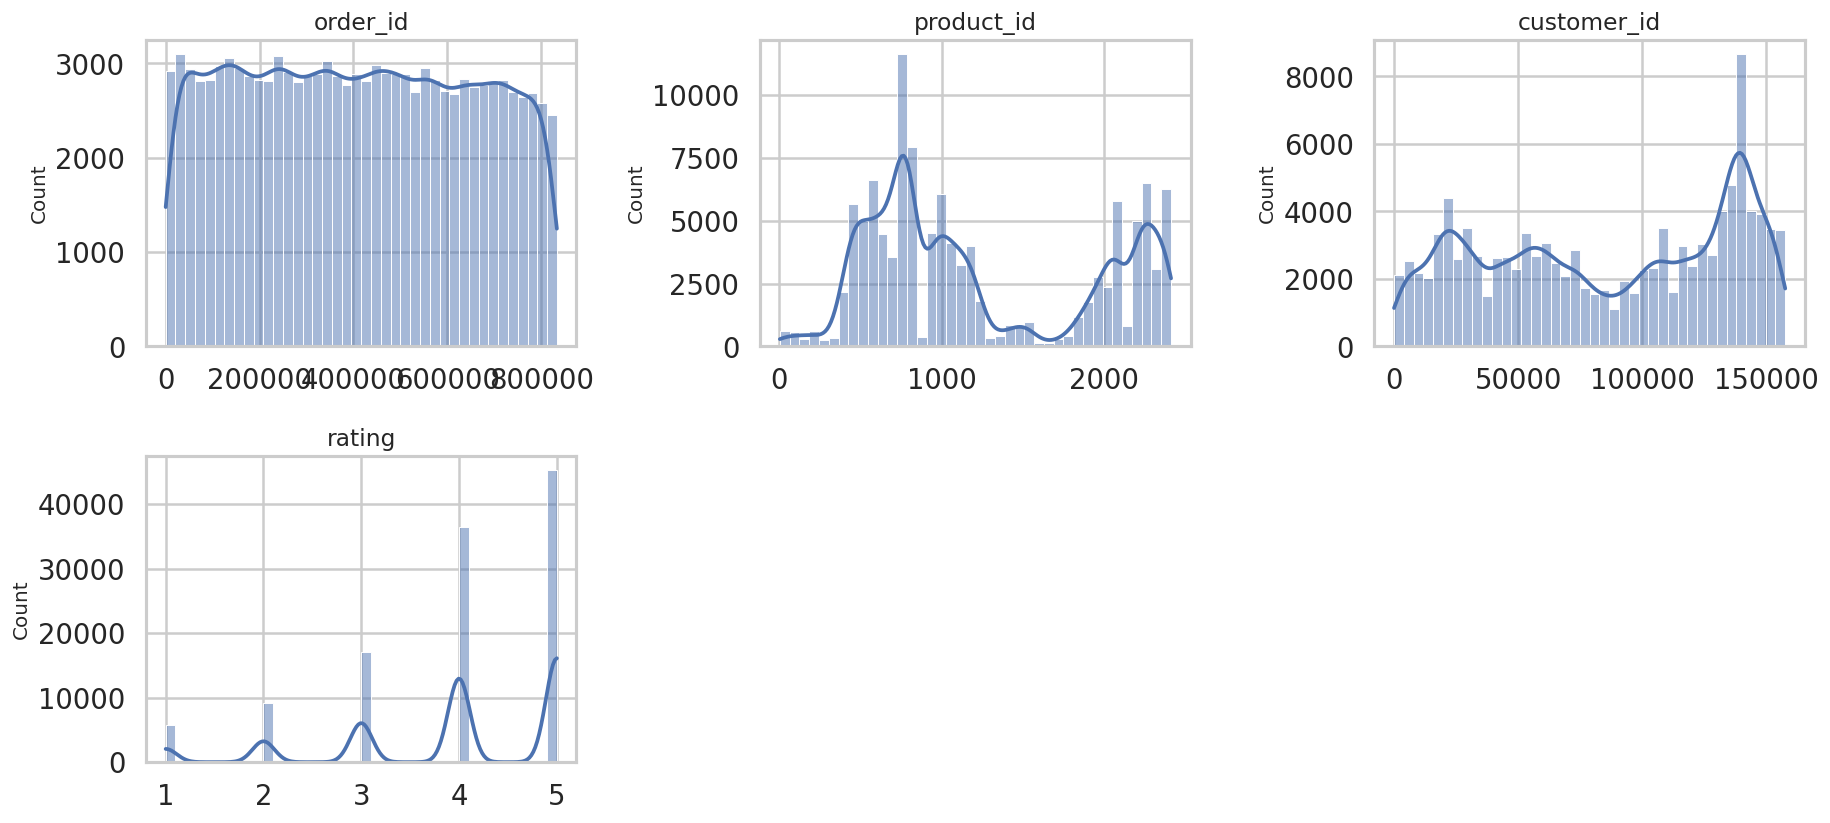

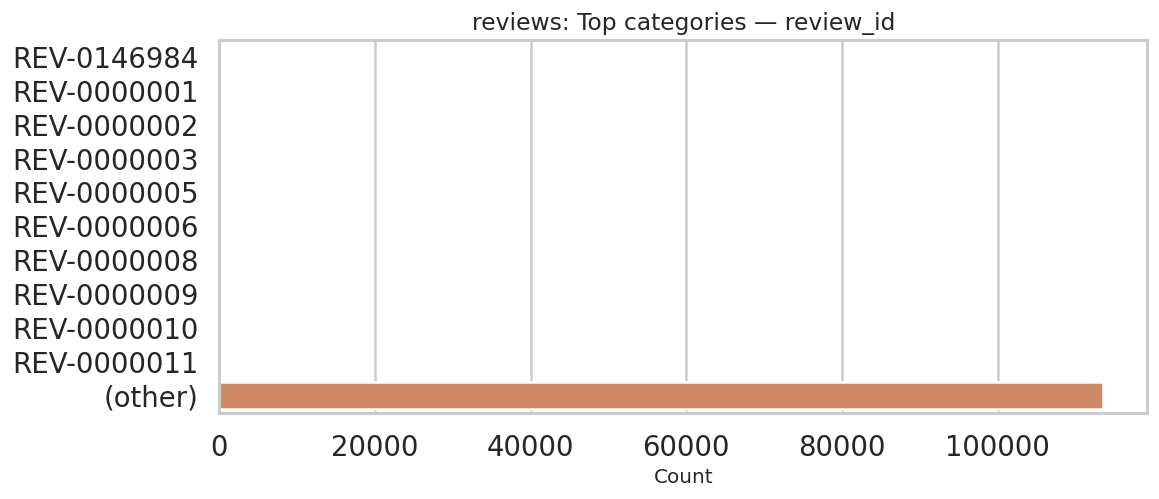

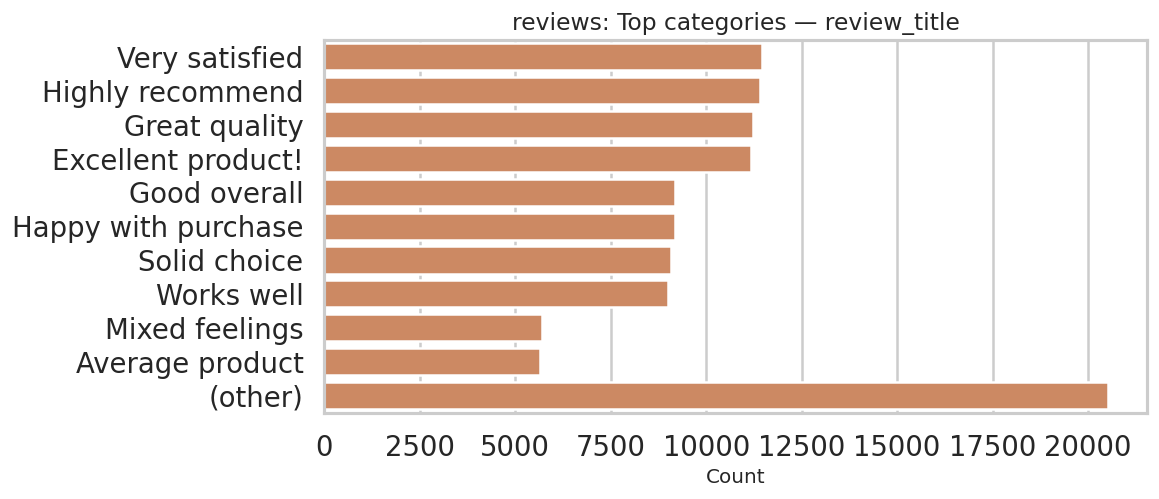

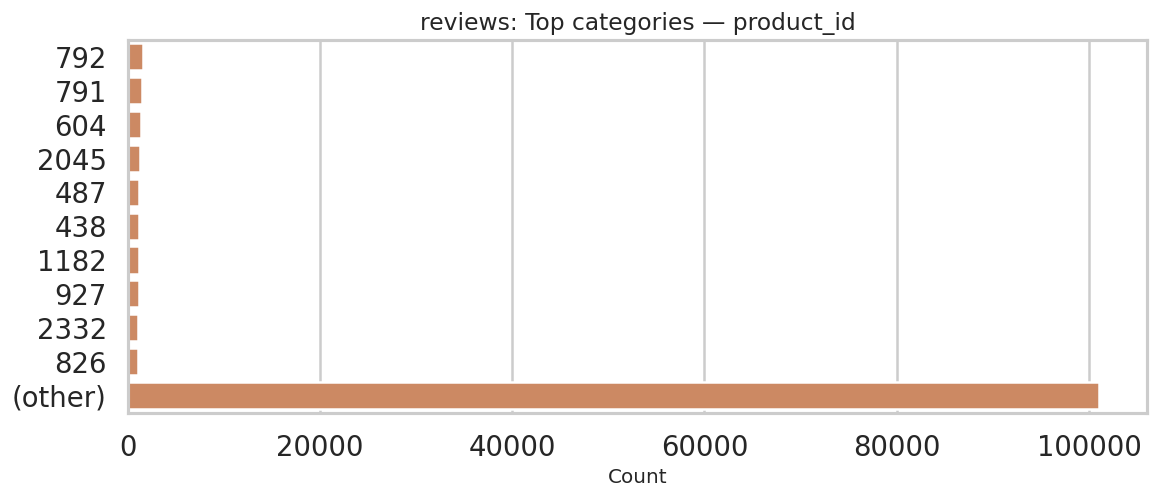

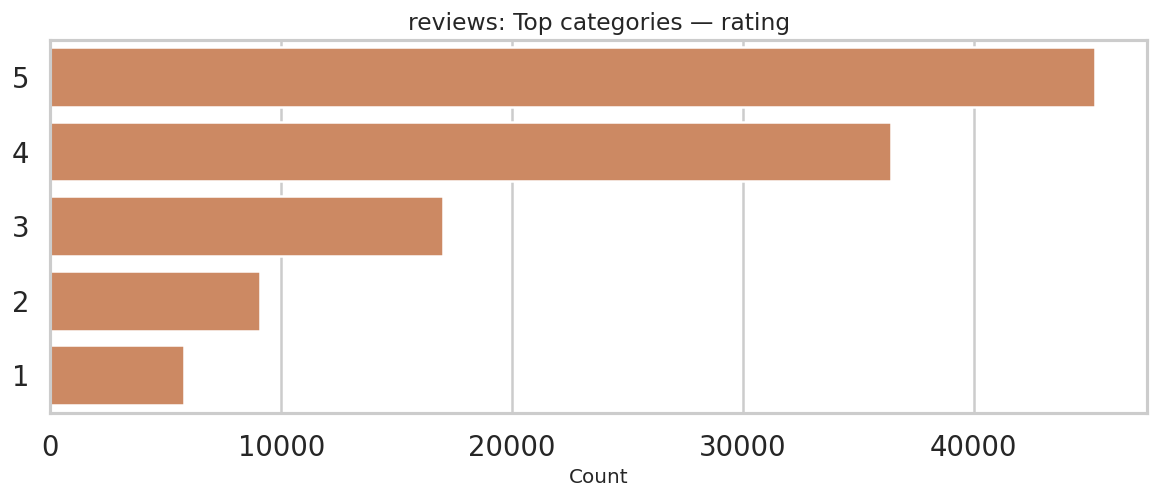

In [5]:
# %% Univariate Analysis
def plot_univariate(
    df: pd.DataFrame,
    *,
    table_name: str,
    max_numeric: int = 12,
    max_categorical: int = 12,
    top_k: int = 10,
    sample_n: int = 200_000,
    random_state: int = 42,
) -> None:
    """Smart univariate plots for a dataframe (numeric + categorical)."""
    if df is None or df.empty:
        print(f"[skip] {table_name}: empty or missing")
        return

    df_plot = df
    if len(df_plot) > sample_n:
        df_plot = df_plot.sample(sample_n, random_state=random_state)

    # Exclude date-like columns from numeric plotting where possible
    date_like = [c for c in df_plot.columns if "date" in c.lower()]
    numeric_cols = [c for c in infer_numeric_cols(df_plot) if c not in date_like]
    cat_cols = [c for c in infer_categorical_cols(df_plot) if c not in date_like]

    numeric_cols = numeric_cols[:max_numeric]
    cat_cols = cat_cols[:max_categorical]

    print(f"\n=== Univariate: {table_name} (n={len(df_plot):,}, p={df_plot.shape[1]}) ===")
    """ MARKDOWN INSIGHT: Start with shape + missingness. For numeric features, look for heavy skew, outliers, and strange spikes (often data entry or encoding issues). For categoricals, watch for dominant single categories, rare levels, and inconsistent labeling (case/typos). """

    if numeric_cols:
        n = len(numeric_cols)
        cols = 3
        rows = int(np.ceil(n / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 5.2, rows * 3.6))
        axes = np.array(axes).reshape(-1)
        for ax, col in zip(axes, numeric_cols, strict=False):
            series = pd.to_numeric(df_plot[col], errors="coerce")
            sns.histplot(series.dropna(), bins=40, kde=True, ax=ax, color=sns.color_palette()[0])
            ax.set_title(col)
            ax.set_xlabel("")
        for ax in axes[len(numeric_cols) :]:
            ax.axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print("No numeric columns detected (after filtering date-like columns).")

    if cat_cols:
        for col in cat_cols:
            vc = df_plot[col].astype("string").fillna("(missing)").value_counts(dropna=False)
            top = vc.head(top_k)
            other = vc.iloc[top_k:].sum()
            if other > 0:
                top = pd.concat([top, pd.Series({"(other)": other})])
            plt.figure(figsize=(10, 4.5))
            sns.barplot(x=top.values, y=top.index, orient="h", color=sns.color_palette()[1])
            plt.title(f"{table_name}: Top categories — {col}")
            plt.xlabel("Count")
            plt.ylabel("")
            plt.tight_layout()
            plt.show()
    else:
        print("No categorical columns detected (or all high-cardinality).")


for key_table in ["orders", "sales", "customers", "reviews"]:
    if key_table in dfs:
        plot_univariate(dfs[key_table], table_name=key_table)
    else:
        print(f"[skip] Missing table: {key_table}")

# Multivariate Analysis

In [6]:
# %% Multivariate Analysis (Prep / Canonical Frames)
orders_df = dfs.get("orders")
order_items_df = dfs.get("order_items")
products_df = dfs.get("products")
customers_df = dfs.get("customers")
geography_df = dfs.get("geography")
promotions_df = dfs.get("promotions")
payments_df = dfs.get("payments")
returns_df = dfs.get("returns")
reviews_df = dfs.get("reviews")
inventory_df = dfs.get("inventory")
shipments_df = dfs.get("shipments")
web_df = dfs.get("web_traffic")
sales_df = dfs.get("sales")

# Normalize key date columns (if present)
if orders_df is not None:
    orders_df, _ = ensure_datetime(orders_df, ["order_date"])
if returns_df is not None:
    returns_df, _ = ensure_datetime(returns_df, ["return_date"])
if reviews_df is not None:
    reviews_df, _ = ensure_datetime(reviews_df, ["review_date"])
if shipments_df is not None:
    shipments_df, _ = ensure_datetime(shipments_df, ["ship_date", "delivery_date"])
if web_df is not None:
    web_df, _ = ensure_datetime(web_df, ["date"])
if sales_df is not None:
    sales_df, _ = ensure_datetime(sales_df, ["Date"])
if inventory_df is not None:
    inventory_df, _ = ensure_datetime(inventory_df, ["snapshot_date"])
if promotions_df is not None:
    promotions_df, _ = ensure_datetime(promotions_df, ["start_date", "end_date"])

# Enriched orders (customers + geography)
orders_enriched = orders_df.copy() if orders_df is not None else None
if orders_enriched is not None:
    orders_enriched = safe_merge(orders_enriched, customers_df, on="customer_id", how="left")
    orders_enriched = safe_merge(orders_enriched, geography_df, on="zip", how="left")

# Order lines (order_items + orders + products)
order_lines = None
if order_items_df is not None:
    order_lines = order_items_df.copy()
    if orders_df is not None and "order_id" in order_lines.columns:
        keep = {"order_id", "order_date", "customer_id", "zip"}
        order_lines = safe_merge(order_lines, orders_df[[c for c in orders_df.columns if c in keep]], on="order_id", how="left")
    if products_df is not None and "product_id" in order_lines.columns:
        prod_keep = {"product_id", "product_name", "category", "segment", "price", "cogs", "size", "color"}
        order_lines = safe_merge(order_lines, products_df[[c for c in products_df.columns if c in prod_keep]], on="product_id", how="left")

    # Standardize pricing columns
    if "discount_amount" in order_lines.columns:
        order_lines["discount_amount"] = pd.to_numeric(order_lines["discount_amount"], errors="coerce").fillna(0.0)
    else:
        order_lines["discount_amount"] = 0.0

    for col in ["quantity", "unit_price"]:
        if col in order_lines.columns:
            order_lines[col] = pd.to_numeric(order_lines[col], errors="coerce")

    if {"quantity", "unit_price"}.issubset(order_lines.columns):
        order_lines["line_gross"] = order_lines["quantity"].astype(float) * order_lines["unit_price"].astype(float)
        order_lines["line_net"] = order_lines["line_gross"] - order_lines["discount_amount"].astype(float)
    else:
        order_lines["line_gross"] = np.nan
        order_lines["line_net"] = np.nan

print("Prepared frames:")
print(f"- orders_enriched: {None if orders_enriched is None else orders_enriched.shape}")
print(f"- order_lines:     {None if order_lines is None else order_lines.shape}")

Prepared frames:
- orders_enriched: (646945, 17)
- order_lines:     (714669, 19)


## Funnel & Conversion (Web Traffic → Promo Usage → Sales)

In [7]:
# %% Funnel & Conversion
""" MARKDOWN INSIGHT: A healthy funnel shows a stable (or improving) conversion from sessions → orders → revenue. If promo usage spikes without a revenue lift, discounts may be cannibalizing margin or attracting low-intent traffic. """

if web_df is None or sales_df is None:
    print("[skip] Need web_traffic and sales for funnel analysis.")
else:
    web = web_df.copy()
    web, web_date = ensure_datetime(web, ["date"])
    if web_date is None:
        print("[skip] web_traffic has no date column")
    else:
        web[web_date] = web[web_date].dt.floor("D")
        agg_web = {
            "sessions": "sum",
            "unique_visitors": "sum",
            "page_views": "sum",
            "bounce_rate": "mean",
            "avg_session_duration_sec": "mean",
        }
        web_cols = [c for c in agg_web if c in web.columns]
        web_daily = (
            web.groupby(web_date, as_index=False)[web_cols]
            .agg({c: agg_web[c] for c in web_cols})
            .rename(columns={web_date: "date"})
        )

        sales = sales_df.copy()
        sales, sales_date = ensure_datetime(sales, ["Date"])
        if sales_date is None:
            print("[skip] sales has no Date column")
        else:
            sales[sales_date] = sales[sales_date].dt.floor("D")
            sales_cols = [c for c in ["Revenue", "COGS"] if c in sales.columns]
            sales_daily = (
                sales.groupby(sales_date, as_index=False)[sales_cols]
                .sum()
                .rename(columns={sales_date: "date"})
            )
            if "Revenue" in sales_daily.columns and "COGS" in sales_daily.columns:
                sales_daily["Gross_Margin"] = sales_daily["Revenue"] - sales_daily["COGS"]

            # Orders daily
            orders_daily = None
            if orders_df is not None and "order_date" in orders_df.columns:
                tmp = orders_df.copy()
                tmp["order_date"] = pd.to_datetime(tmp["order_date"], errors="coerce").dt.floor("D")
                orders_daily = tmp.groupby("order_date", as_index=False).agg(
                    orders=("order_id", "nunique") if "order_id" in tmp.columns else ("order_date", "size"),
                    purchasers=("customer_id", "nunique") if "customer_id" in tmp.columns else ("order_date", "size"),
                ).rename(columns={"order_date": "date"})

            # Promo usage daily (share of order_items lines with promo_id)
            promo_daily = None
            if order_items_df is not None:
                oi = order_items_df.copy()
                promo_cols = [c for c in ["promo_id", "promo_id_2"] if c in oi.columns]
                if promo_cols and orders_df is not None and "order_id" in oi.columns and "order_date" in orders_df.columns:
                    oi = safe_merge(oi, orders_df[["order_id", "order_date"]], on="order_id", how="left")
                    oi["order_date"] = pd.to_datetime(oi["order_date"], errors="coerce").dt.floor("D")
                    promo_any = np.zeros(len(oi), dtype=bool)
                    for pc in promo_cols:
                        promo_any |= oi[pc].notna().to_numpy()
                    oi["promo_any"] = promo_any
                    if "discount_amount" in oi.columns:
                        oi["discount_amount"] = pd.to_numeric(oi["discount_amount"], errors="coerce")
                    promo_daily = (
                        oi.groupby("order_date", as_index=False).agg(
                            promo_usage_rate=("promo_any", "mean"),
                            discount_amount=("discount_amount", "sum") if "discount_amount" in oi.columns else ("promo_any", "size"),
                            line_items=("order_id", "size"),
                        ).rename(columns={"order_date": "date"})
                    )

            # Assemble daily frame (inner join on overlapping dates)
            daily = web_daily.merge(sales_daily, on="date", how="inner")
            if orders_daily is not None:
                daily = daily.merge(orders_daily, on="date", how="left")
            if promo_daily is not None:
                daily = daily.merge(promo_daily, on="date", how="left")

            daily = daily.sort_values("date")
            display(daily.head())

            # Time series: sessions vs revenue + promo usage
            fig = make_subplots(
                rows=2,
                cols=1,
                shared_xaxes=True,
                vertical_spacing=0.08,
                specs=[[{"secondary_y": True}], [{"secondary_y": True}]],
                row_heights=[0.62, 0.38],
            )

            if "sessions" in daily.columns:
                fig.add_trace(
                    go.Scatter(x=daily["date"], y=daily["sessions"], name="Sessions", mode="lines"),
                    row=1,
                    col=1,
                    secondary_y=False,
                )
            if "Revenue" in daily.columns:
                fig.add_trace(
                    go.Scatter(
                        x=daily["date"],
                        y=daily["Revenue"],
                        name="Revenue",
                        mode="lines",
                        line=dict(width=3),
                    ),
                    row=1,
                    col=1,
                    secondary_y=True,
                )
            if "promo_usage_rate" in daily.columns:
                fig.add_trace(
                    go.Scatter(
                        x=daily["date"],
                        y=100.0 * daily["promo_usage_rate"].fillna(0.0),
                        name="Promo usage (%)",
                        mode="lines",
                        line=dict(dash="dot"),
                    ),
                    row=2,
                    col=1,
                    secondary_y=False,
                )
            if "discount_amount" in daily.columns:
                fig.add_trace(
                    go.Bar(
                        x=daily["date"],
                        y=daily["discount_amount"].fillna(0.0),
                        name="Discount amount",
                        opacity=0.45,
                    ),
                    row=2,
                    col=1,
                    secondary_y=True,
                )

            fig.update_layout(
                title="Funnel signals over time: Traffic, Sales, Promotions",
                height=720,
                legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
                margin=dict(l=40, r=40, t=60, b=40),
            )
            fig.update_yaxes(title_text="Sessions", row=1, col=1, secondary_y=False)
            fig.update_yaxes(title_text="Revenue", row=1, col=1, secondary_y=True)
            fig.update_yaxes(title_text="Promo usage (%)", row=2, col=1, secondary_y=False)
            fig.update_yaxes(title_text="Discount amount", row=2, col=1, secondary_y=True)
            fig.show()

            # Scatter: sessions vs revenue colored by promo usage
            if "sessions" in daily.columns and "Revenue" in daily.columns:
                color_col = "promo_usage_rate" if "promo_usage_rate" in daily.columns else None
                fig2 = px.scatter(
                    daily,
                    x="sessions",
                    y="Revenue",
                    color=color_col,
                    size="orders" if "orders" in daily.columns else None,
                    title="Traffic vs Revenue (color = promo usage rate)",
                    labels={"sessions": "Sessions", "Revenue": "Revenue"},
                )
                fig2.update_traces(marker=dict(opacity=0.75))
                fig2 = add_regression_line(
                    fig2,
                    x=daily["sessions"].to_numpy(dtype=float),
                    y=daily["Revenue"].to_numpy(dtype=float),
                    name="Linear trend",
                )
                fig2.show()

            # Simple funnel summary (overlapping period)
            if orders_df is not None and "order_date" in orders_df.columns and "sessions" in daily.columns:
                total_sessions = float(daily["sessions"].sum())
                total_orders = float(daily.get("orders", pd.Series([np.nan])).sum())
                total_revenue = float(daily.get("Revenue", pd.Series([np.nan])).sum())
                conv = (total_orders / total_sessions) if total_sessions else np.nan
                fig3 = go.Figure(
                    data=[
                        go.Bar(
                            x=["Sessions", "Orders", "Revenue"],
                            y=[total_sessions, total_orders, total_revenue],
                            text=[f"{total_sessions:,.0f}", f"{total_orders:,.0f}", f"{total_revenue:,.0f}"],
                            textposition="auto",
                        )
                    ]
                )
                fig3.update_layout(
                    title=f"Aggregate funnel (overlap period) — Orders/Sessions = {conv:.2%}",
                    height=420,
                )
                fig3.show()

,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,Revenue,COGS,Gross_Margin,orders,purchasers,promo_usage_rate,discount_amount,line_items
0,2013-01-01,9760,7253,39093,0.01,102.90,5304546.99,4156070.20,1148476.79,288,283,0.00,0.00,356
1,2013-01-02,10456,8151,47611,0.00,120.50,1606940.44,1237497.84,369442.60,47,47,0.00,0.00,57
2,2013-01-03,10076,7458,36963,0.00,263.60,2281680.01,1832133.02,449546.99,81,80,0.00,0.00,93
3,2013-01-04,9973,8063,53078,0.01,151.80,2376895.46,1940747.07,436148.39,83,82,0.00,0.00,97
4,2013-01-05,10223,7882,36790,0.01,168.60,2509462.77,1977027.71,532435.06,78,77,0.00,0.00,90


## Product Performance (Sales + Inventory + Returns by Category)

In [8]:
# %% Product Performance
""" MARKDOWN INSIGHT: Categories with high revenue + low inventory can indicate stock constraints (lost sales). High return rates alongside high volume often point to product quality/fit issues or misleading merchandising. """

if order_lines is None or order_lines.empty:
    print("[skip] Need order_items (+ orders/products) to compute product performance.")
else:
    df = order_lines.copy()
    cat_col = pick_first_existing(df, ["category", "segment"])
    if cat_col is None:
        print("[skip] No category/segment column available to group product performance.")
    else:
        # Sales volume / revenue by category
        sold = df.groupby(cat_col, as_index=False).agg(
            units_sold=("quantity", "sum") if "quantity" in df.columns else (cat_col, "size"),
            net_revenue=("line_net", "sum") if "line_net" in df.columns else (cat_col, "size"),
            orders=("order_id", "nunique") if "order_id" in df.columns else (cat_col, "size"),
        )

        # Returns rate by category
        returns_cat = None
        if returns_df is not None and products_df is not None and "product_id" in returns_df.columns:
            ret = returns_df.copy()
            ret_qty_col = pick_first_existing(ret, ["return_quantity", "quantity", "qty"])
            if ret_qty_col is None:
                ret["return_quantity"] = 1.0
                ret_qty_col = "return_quantity"
            ret[ret_qty_col] = pd.to_numeric(ret[ret_qty_col], errors="coerce")
            prod_keep = [c for c in products_df.columns if c in {"product_id", "category", "segment"}]
            ret = safe_merge(ret, products_df[prod_keep], on="product_id", how="left")
            ret_cat_col = pick_first_existing(ret, ["category", "segment"])
            if ret_cat_col is not None:
                returns_cat = ret.groupby(ret_cat_col, as_index=False).agg(returns_qty=(ret_qty_col, "sum"))
                returns_cat = returns_cat.rename(columns={ret_cat_col: cat_col})

        kpi = sold.copy()
        if returns_cat is not None:
            kpi = kpi.merge(returns_cat, on=cat_col, how="left")
            kpi["returns_qty"] = kpi["returns_qty"].fillna(0.0)
            kpi["return_rate"] = kpi["returns_qty"] / kpi["units_sold"].replace({0: np.nan})
        else:
            kpi["return_rate"] = np.nan

        # Inventory by category (latest snapshot per product)
        inv_cat = None
        if inventory_df is not None and "product_id" in inventory_df.columns:
            inv = inventory_df.copy()
            inv, inv_date = ensure_datetime(inv, ["snapshot_date"])
            stock_col = pick_first_existing(inv, ["stock_on_hand", "stock", "inventory", "on_hand"])
            if inv_date is not None and stock_col is not None:
                inv[stock_col] = pd.to_numeric(inv[stock_col], errors="coerce")
                inv = inv.sort_values(inv_date)
                latest = inv.groupby("product_id", as_index=False).tail(1)
                # Category mapping: prefer inventory category; else join products
                inv_cat_col = pick_first_existing(latest, ["category", "segment"])
                if inv_cat_col is None and products_df is not None:
                    prod_keep = [c for c in products_df.columns if c in {"product_id", "category", "segment"}]
                    latest = safe_merge(latest, products_df[prod_keep], on="product_id", how="left")
                    inv_cat_col = pick_first_existing(latest, ["category", "segment"])
                if inv_cat_col is not None:
                    inv_cat = latest.groupby(inv_cat_col, as_index=False).agg(stock_on_hand=(stock_col, "sum"))
                    inv_cat = inv_cat.rename(columns={inv_cat_col: cat_col})

        if inv_cat is not None:
            kpi = kpi.merge(inv_cat, on=cat_col, how="left")
        else:
            kpi["stock_on_hand"] = np.nan

        kpi = kpi.sort_values("net_revenue", ascending=False)
        display(kpi.head(10))

        # Chart: revenue (bar) + stock (line) + return rate (markers)
        plot_df = kpi.head(15).copy()
        fig = make_subplots(specs=[[{"secondary_y": True}]])
        fig.add_trace(
            go.Bar(x=plot_df[cat_col], y=plot_df["net_revenue"], name="Net revenue"),
            secondary_y=False,
        )
        if plot_df["stock_on_hand"].notna().any():
            fig.add_trace(
                go.Scatter(
                    x=plot_df[cat_col],
                    y=plot_df["stock_on_hand"],
                    name="Stock on hand (latest)",
                    mode="lines+markers",
                    line=dict(width=3),
                ),
                secondary_y=True,
            )
        if plot_df["return_rate"].notna().any():
            fig.add_trace(
                go.Scatter(
                    x=plot_df[cat_col],
                    y=100.0 * plot_df["return_rate"],
                    name="Return rate (%)",
                    mode="markers",
                    marker=dict(size=10, symbol="diamond"),
                ),
                secondary_y=True,
            )
        fig.update_layout(
            title="Category performance: Revenue vs Inventory vs Returns (Top 15)",
            height=520,
            margin=dict(l=40, r=40, t=60, b=40),
            legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
        )
        fig.update_yaxes(title_text="Net revenue", secondary_y=False)
        fig.update_yaxes(title_text="Stock / Return rate", secondary_y=True)
        fig.show()

,category,units_sold,net_revenue,orders,returns_qty,return_rate,stock_on_hand
3,Streetwear,1768826,12558477099.17,389543,59801,0.03,110851
2,Outdoor,1170000,2353396796.86,200454,40417,0.03,71636
0,Casual,107469,440285193.75,23600,3499,0.03,5924
1,GenZ,166848,328710175.65,37054,5869,0.04,10037


## Customer Geography (Orders + Payments across Regions)

,region,district,city,orders,customers
512,West,District #38,Pleiku,3324,136
501,West,District #37,Vung Tau,2984,151
293,East,District #10,Thai Nguyen,2835,215
498,West,District #37,Soc Trang,2576,143
509,West,District #38,Ho Chi Minh City,2557,149
28,Central,District #22,Kon Tum,2436,253
506,West,District #38,Ca Mau,2277,158
429,West,District #33,Ho Chi Minh City,2264,214
37,Central,District #23,Dong Hoi,2239,242
477,West,District #36,Ho Chi Minh City,2221,163


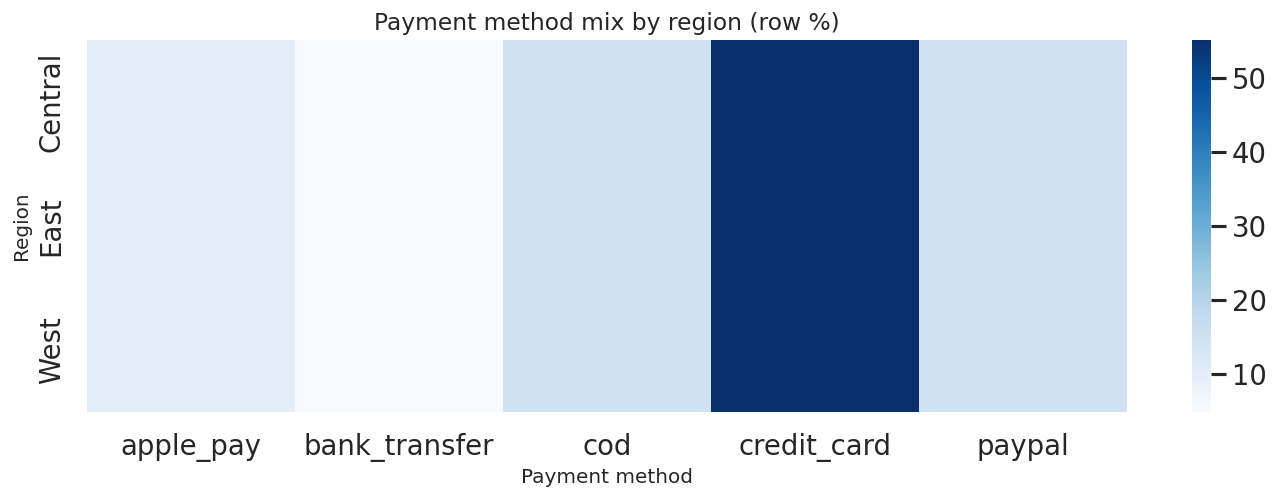

In [9]:
# %% Customer Geography
""" MARKDOWN INSIGHT: Geography breakdowns highlight demand concentration and potential operational mismatches. Pair orders with payment value/method to detect regional payment friction or differing customer value. """

if orders_enriched is None or orders_enriched.empty:
    print("[skip] Need orders (+ geography/customers) to analyze geography.")
else:
    geo = orders_enriched.copy()
    region_col = pick_first_existing(geo, ["region"])
    district_col = pick_first_existing(geo, ["district"])
    city_col = pick_first_existing(geo, ["city"])
    if region_col is None:
        print("[skip] No region column available (check geography join on zip).")
    else:
        base_cols = [c for c in [region_col, district_col, city_col] if c is not None]
        value_col = "order_id" if "order_id" in geo.columns else None
        geo_kpi = geo.groupby(base_cols, as_index=False).agg(
            orders=(value_col, "nunique") if value_col else (base_cols[0], "size"),
            customers=("customer_id", "nunique") if "customer_id" in geo.columns else (base_cols[0], "size"),
        )
        geo_kpi = geo_kpi.sort_values("orders", ascending=False)
        display(geo_kpi.head(15))

        # Payments join (optional)
        pay_kpi = None
        if payments_df is not None and "order_id" in payments_df.columns and "order_id" in geo.columns:
            pay = payments_df.copy()
            if "payment_value" in pay.columns:
                pay["payment_value"] = pd.to_numeric(pay["payment_value"], errors="coerce")
            pay = safe_merge(pay, geo[["order_id", region_col]], on="order_id", how="left")
            if "payment_value" in pay.columns:
                pay_kpi = pay.groupby(region_col, as_index=False).agg(
                    payment_value=("payment_value", "sum"),
                    orders=("order_id", "nunique"),
                )
                pay_kpi["aov"] = pay_kpi["payment_value"] / pay_kpi["orders"].replace({0: np.nan})

        # Treemap: orders by geo hierarchy
        treemap_path = [c for c in [region_col, district_col, city_col] if c is not None]
        fig = px.treemap(
            geo_kpi,
            path=treemap_path,
            values="orders",
            title="Orders distribution across geography",
        )
        fig.update_layout(margin=dict(l=20, r=20, t=60, b=20), height=520)
        fig.show()

        # Heatmap: payment method share by region
        if payments_df is not None and "payment_method" in payments_df.columns and "order_id" in payments_df.columns:
            pay2 = payments_df.copy()
            pay2 = safe_merge(pay2, geo[["order_id", region_col]], on="order_id", how="left")
            if region_col in pay2.columns:
                ctab = pd.crosstab(pay2[region_col], pay2["payment_method"], normalize="index")
                plt.figure(figsize=(12, max(4.5, 0.35 * len(ctab))))
                sns.heatmap(100.0 * ctab, annot=False, cmap="Blues")
                plt.title("Payment method mix by region (row %)")
                plt.xlabel("Payment method")
                plt.ylabel("Region")
                plt.tight_layout()
                plt.show()

        if pay_kpi is not None:
            fig2 = px.bar(
                pay_kpi.sort_values("payment_value", ascending=False),
                x=region_col,
                y="payment_value",
                title="Total payment value by region",
            )
            fig2.update_layout(height=420, margin=dict(l=40, r=20, t=60, b=40))
            fig2.show()

## Sentiment vs Performance (Reviews ↔ Returns / Sales)

,product_id,avg_rating,review_count,units_sold,net_revenue,returns_qty,return_rate,category,segment
493,792,3.91,1596,45726,31115132.00,1732.00,0.04,Outdoor,Activewear
492,791,3.95,1512,45986,31270865.58,1577.00,0.03,Outdoor,Activewear
369,604,4.00,1364,36515,198996641.52,1169.00,0.03,Streetwear,Everyday
1218,2045,3.91,1323,35844,177036251.49,1089.00,0.03,Streetwear,Performance
273,487,3.93,1190,33277,380468714.41,1129.00,0.03,Streetwear,Balanced
237,438,3.89,1148,31471,325014877.63,971.00,0.03,Streetwear,Balanced
715,1182,4.02,1135,31896,63056050.51,1079.00,0.03,Streetwear,Performance
543,927,3.96,1126,31220,160923326.77,1121.00,0.04,Streetwear,Performance
1364,2332,3.95,1109,32821,170367241.47,1139.00,0.03,Streetwear,Performance
514,826,3.82,1039,28993,327509101.46,996.00,0.03,Streetwear,Balanced


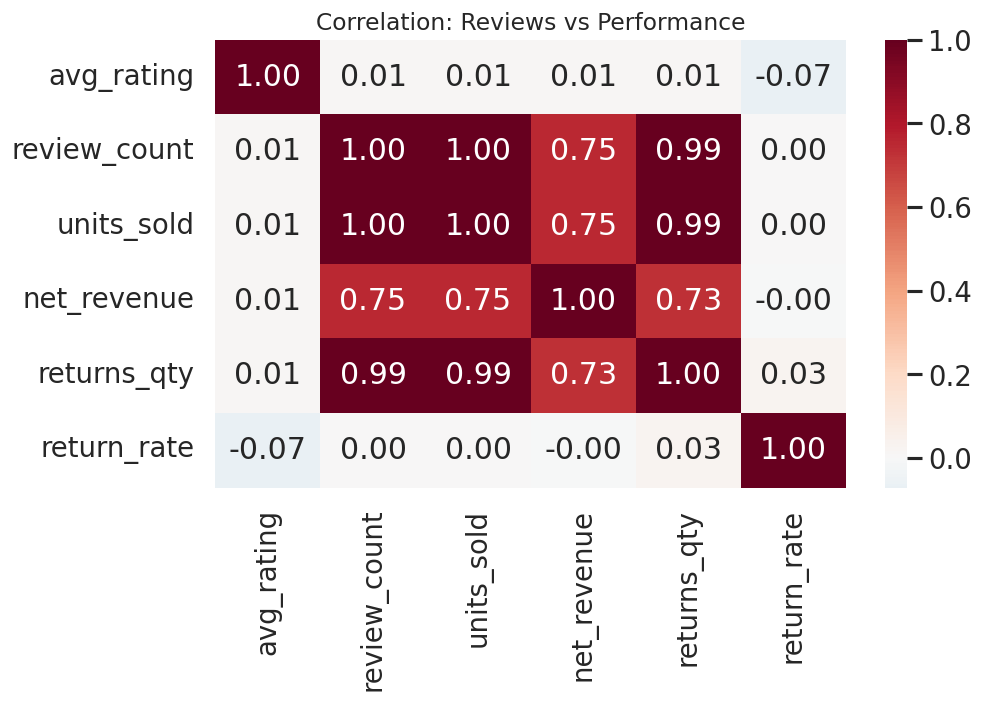

In [10]:
# %% Sentiment vs Performance
""" MARKDOWN INSIGHT: If ratings are predictive of returns, you should see a negative relationship (higher rating → lower return rate). Outliers (high rating + high returns) often indicate fulfillment/packaging issues or expectation mismatch rather than product quality. """

if reviews_df is None or reviews_df.empty:
    print("[skip] Need reviews to analyze sentiment.")
else:
    rev = reviews_df.copy()
    rating_col = pick_first_existing(rev, ["rating", "score", "stars"])
    if rating_col is None:
        print("[skip] No rating column in reviews.")
    elif "product_id" not in rev.columns:
        print("[skip] reviews missing product_id.")
    else:
        rev[rating_col] = pd.to_numeric(rev[rating_col], errors="coerce")
        prod_reviews = rev.groupby("product_id", as_index=False).agg(
            avg_rating=(rating_col, "mean"),
            review_count=(rating_col, "size"),
        )

        # Product sales metrics from order_lines
        prod_sales = None
        if order_lines is not None and "product_id" in order_lines.columns:
            prod_sales = order_lines.groupby("product_id", as_index=False).agg(
                units_sold=("quantity", "sum") if "quantity" in order_lines.columns else ("product_id", "size"),
                net_revenue=("line_net", "sum") if "line_net" in order_lines.columns else ("product_id", "size"),
            )

        # Product returns rate
        prod_returns = None
        if returns_df is not None and "product_id" in returns_df.columns:
            ret = returns_df.copy()
            qty_col = pick_first_existing(ret, ["return_quantity", "quantity", "qty"])
            if qty_col is None:
                ret["return_quantity"] = 1.0
                qty_col = "return_quantity"
            ret[qty_col] = pd.to_numeric(ret[qty_col], errors="coerce")
            prod_returns = ret.groupby("product_id", as_index=False).agg(returns_qty=(qty_col, "sum"))

        metrics = prod_reviews.copy()
        if prod_sales is not None:
            metrics = metrics.merge(prod_sales, on="product_id", how="left")
        if prod_returns is not None:
            metrics = metrics.merge(prod_returns, on="product_id", how="left")
        metrics["returns_qty"] = metrics.get("returns_qty", 0.0).fillna(0.0)
        metrics["units_sold"] = metrics.get("units_sold", np.nan)
        metrics["return_rate"] = metrics["returns_qty"] / metrics["units_sold"].replace({0: np.nan})

        # Add category for coloring
        if products_df is not None and "product_id" in products_df.columns:
            cat = products_df[[c for c in products_df.columns if c in {"product_id", "category", "segment"}]].copy()
            metrics = metrics.merge(cat, on="product_id", how="left")
        cat_col = pick_first_existing(metrics, ["category", "segment"])

        display(metrics.sort_values("review_count", ascending=False).head(10))

        # Scatter: rating vs return rate
        plot_df = metrics.dropna(subset=["avg_rating"]).copy()
        if "return_rate" in plot_df.columns and plot_df["return_rate"].notna().any():
            fig = px.scatter(
                plot_df,
                x="avg_rating",
                y="return_rate",
                size="review_count",
                color=cat_col,
                hover_data=["product_id"],
                title="Avg rating vs Return rate (size = review count)",
                labels={"avg_rating": "Average rating", "return_rate": "Return rate"},
            )
            fig.update_traces(marker=dict(opacity=0.75))
            fig = add_regression_line(
                fig,
                x=plot_df["avg_rating"].to_numpy(dtype=float),
                y=plot_df["return_rate"].to_numpy(dtype=float),
                name="Linear trend",
            )
            fig.show()
        else:
            print("[note] Return rate not available; showing rating vs revenue instead.")

        if "net_revenue" in plot_df.columns and plot_df["net_revenue"].notna().any():
            fig2 = px.scatter(
                plot_df,
                x="avg_rating",
                y="net_revenue",
                size="review_count",
                color=cat_col,
                hover_data=["product_id"],
                title="Avg rating vs Net revenue (size = review count)",
                labels={"avg_rating": "Average rating", "net_revenue": "Net revenue"},
            )
            fig2.update_traces(marker=dict(opacity=0.75))
            fig2 = add_regression_line(
                fig2,
                x=plot_df["avg_rating"].to_numpy(dtype=float),
                y=plot_df["net_revenue"].to_numpy(dtype=float),
                name="Linear trend",
            )
            fig2.show()

        # Correlation heatmap (numeric metrics)
        numeric_cols = [c for c in ["avg_rating", "review_count", "units_sold", "net_revenue", "returns_qty", "return_rate"] if c in metrics.columns]
        corr = metrics[numeric_cols].corr(numeric_only=True)
        plt.figure(figsize=(8.8, 6.2))
        sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, fmt=".2f")
        plt.title("Correlation: Reviews vs Performance")
        plt.tight_layout()
        plt.show()

# Executive Summary

In [11]:
# %% Executive Summary
""" MARKDOWN INSIGHT: These bullets are programmatic summaries from computed KPI tables. Treat them as hypotheses to validate with deeper cohort cuts (by channel, promo type, customer segment, and seasonality). """

insights: List[str] = []

# 1) Funnel efficiency
if "daily" in globals() and isinstance(globals().get("daily"), pd.DataFrame):
    _daily = globals()["daily"].copy()
    if {"sessions", "Revenue"}.issubset(_daily.columns):
        revenue_per_session = float(_daily["Revenue"].sum()) / max(float(_daily["sessions"].sum()), 1.0)
        insights.append(f"Traffic efficiency: Revenue per session ≈ {revenue_per_session:.4f}")
    if {"sessions", "orders"}.issubset(_daily.columns):
        conv = float(_daily["orders"].sum()) / max(float(_daily["sessions"].sum()), 1.0)
        insights.append(f"Conversion: Orders / Sessions ≈ {conv:.2%}")
    if "promo_usage_rate" in _daily.columns and _daily["promo_usage_rate"].notna().any():
        insights.append(f"Promo intensity: Avg promo usage rate ≈ {_daily['promo_usage_rate'].mean():.2%}")

# 2) Category leaders / risks
if "kpi" in globals() and isinstance(globals().get("kpi"), pd.DataFrame):
    _kpi = globals()["kpi"].copy()
    if "net_revenue" in _kpi.columns:
        top_cat = _kpi.sort_values("net_revenue", ascending=False).head(1)
        if not top_cat.empty:
            cat_name = str(top_cat.iloc[0][_kpi.columns[0]])
            insights.append(f"Top category by net revenue: {cat_name}")
    if "return_rate" in _kpi.columns and _kpi["return_rate"].notna().any():
        worst = _kpi.sort_values("return_rate", ascending=False).head(1)
        if not worst.empty:
            cat_name = str(worst.iloc[0][_kpi.columns[0]])
            rr = float(worst.iloc[0]["return_rate"])
            insights.append(f"Highest category return rate: {cat_name} (≈ {rr:.2%})")
    if "stock_on_hand" in _kpi.columns and _kpi["stock_on_hand"].notna().any():
        low_stock = _kpi.sort_values("stock_on_hand", ascending=True).head(1)
        if not low_stock.empty:
            cat_name = str(low_stock.iloc[0][_kpi.columns[0]])
            insights.append(f"Lowest inventory (latest): {cat_name} — validate potential stock constraints")

# 3) Regional concentration
if orders_enriched is not None:
    reg = pick_first_existing(orders_enriched, ["region"])
    if reg is not None:
        by_reg = orders_enriched.groupby(reg).size().sort_values(ascending=False)
        if not by_reg.empty:
            insights.append(f"Top region by order count: {by_reg.index[0]} ({int(by_reg.iloc[0]):,} orders)")

# 4) Sentiment linkage
if "metrics" in globals() and isinstance(globals().get("metrics"), pd.DataFrame):
    m = globals()["metrics"].copy()
    if {"avg_rating", "return_rate"}.issubset(m.columns) and m["return_rate"].notna().any():
        corr = m[["avg_rating", "return_rate"]].corr(numeric_only=True).iloc[0, 1]
        insights.append(f"Rating vs Return rate correlation: {corr:.2f} (directional signal)")

print("\nExecutive Summary (auto-generated):")
if insights:
    for i, s in enumerate(insights, start=1):
        print(f"{i}. {s}")
else:
    print("No summary insights available (missing upstream tables/metrics).")


Executive Summary (auto-generated):
1. Traffic efficiency: Revenue per session ≈ 171.5532
2. Conversion: Orders / Sessions ≈ 0.67%
3. Promo intensity: Avg promo usage rate ≈ 38.66%
4. Top category by net revenue: Streetwear
5. Highest category return rate: GenZ (≈ 3.52%)
6. Lowest inventory (latest): Casual — validate potential stock constraints
7. Top region by order count: East (294,612 orders)
8. Rating vs Return rate correlation: -0.07 (directional signal)


## Question 2: Which product segment in products.csv (product dataframe) has the highest average gross profit margin (calculated as (price−cogs)/price)?

In [12]:
products_df = load_table_safe("products")
products_df.head()

,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.84
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.08,5393.87
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.63,11371.92
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.72,8573.17
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.33,14063.57


In [13]:
products_df['gross_profit_margin'] = (products_df['price'] - products_df['cogs']) / products_df['price']

# 2. Group by 'segment' and calculate the mean (average) of the new margin column
segment_margins = products_df.groupby('segment')['gross_profit_margin'].mean()

# 3. Sort the results in descending order to see the highest at the top
sorted_segments = segment_margins.sort_values(ascending=False)

# 4. Extract the segment with the highest average
highest_segment = sorted_segments.index[0]
highest_margin = sorted_segments.iloc[0]

# Display the results
print("Average Gross Profit Margin by Segment:")
print(sorted_segments)
print(f"\nThe product segment with the highest average gross profit margin is '{highest_segment}' at {highest_margin:.2%}.")

Average Gross Profit Margin by Segment:
segment
Standard      0.31
Premium       0.29
All-weather   0.28
Activewear    0.27
Performance   0.26
Balanced      0.26
Trendy        0.24
Everyday      0.24
Name: gross_profit_margin, dtype: float64

The product segment with the highest average gross profit margin is 'Standard' at 31.34%.


-> D: Standard

## Question 4: In `web_traffic.csv`, which traffic source (`traffic_source`) has the lowest average bounce rate (`bounce_rate`) across all days on which that source appears in the `traffic_source` column?


In [14]:
web_traffic_df = load_table_safe("web_traffic")
web_traffic_df.head()

,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source
0,2013-01-01,9760,7253,39093,0.01,102.90,organic_search
1,2013-01-02,10456,8151,47611,0.00,120.50,organic_search
2,2013-01-03,10076,7458,36963,0.00,263.60,direct
3,2013-01-04,9973,8063,53078,0.01,151.80,direct
4,2013-01-05,10223,7882,36790,0.01,168.60,referral


In [15]:
# 1. Group by 'traffic_source' and calculate the mean (average) of 'bounce_rate'
avg_bounce_rates = web_traffic_df.groupby('traffic_source')['bounce_rate'].mean()

# 2. Sort the results in ascending order to see the lowest at the top
sorted_bounce_rates = avg_bounce_rates.sort_values(ascending=True)

# 3. Extract the traffic source with the lowest average
lowest_source = sorted_bounce_rates.index[0]
lowest_rate = sorted_bounce_rates.iloc[0]

# Display the results
print("Average Bounce Rate by Traffic Source:")
print(sorted_bounce_rates)
print(f"\nThe traffic source with the lowest average bounce rate is '{lowest_source}' at {lowest_rate:.4f}.")

Average Bounce Rate by Traffic Source:
traffic_source
email_campaign   0.00
social_media     0.00
paid_search      0.00
referral         0.00
organic_search   0.00
direct           0.00
Name: bounce_rate, dtype: float64

The traffic source with the lowest average bounce rate is 'email_campaign' at 0.0045.


=> C

## Question 6: In `customers.csv`, considering only customers whose `age_group` is not null, which age group has the highest average number of orders per customer (total number of orders divided by the number of customers in that group)?


In [16]:
customers_df = load_table_safe("customers")
customers_df.head()

,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search
3,4,15201,Hai Phong,2017-11-29,Male,35-44,referral
4,5,15201,Hai Phong,2022-09-23,Male,55+,organic_search


In [17]:
# Assuming there is an 'orders' table you can load
orders_df = load_table_safe("orders")

# 1. Filter the customers dataframe to only include rows where 'age_group' is NOT null
filtered_customers = customers_df.dropna(subset=['age_group'])

# 2. Merge the filtered customers with the orders dataframe
# A 'left' merge ensures we keep customers even if they have 0 orders
merged_df = filtered_customers.merge(orders_df, on='customer_id', how='left')

# 3. Group by 'age_group' and calculate the two metrics needed for your formula
# - total_orders: counts the number of non-null order_ids
# - total_customers: counts the number of unique customer_ids
grouped_data = merged_df.groupby('age_group').agg(
    total_orders=('order_id', 'count'),       
    total_customers=('customer_id', 'nunique') 
)

# 4. Calculate the average number of orders per customer (the formula from the prompt)
grouped_data['avg_orders_per_customer'] = grouped_data['total_orders'] / grouped_data['total_customers']

# 5. Sort the results in descending order to find the highest
sorted_results = grouped_data.sort_values(by='avg_orders_per_customer', ascending=False)

# Extract the top result
highest_age_group = sorted_results.index[0]
highest_avg = sorted_results.iloc[0]['avg_orders_per_customer']

# Display the results
print(sorted_results[['avg_orders_per_customer']])
print(f"\nThe age group with the highest average number of orders per customer is '{highest_age_group}' with an average of {highest_avg:.2f}.")

           avg_orders_per_customer
age_group                         
55+                           5.41
45-54                         5.36
35-44                         5.34
25-34                         5.25
18-24                         5.23

The age group with the highest average number of orders per customer is '55+' with an average of 5.41.


## Question 8: In `orders.csv`, among orders with `order_status = 'cancelled'`, which payment method is used most frequently?


In [18]:
orders_df = load_table_safe("orders")
orders_df.head()


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign


In [19]:
# 1. Filter the dataframe to only include rows where order_status is 'cancelled'
cancelled_orders = orders_df[orders_df['order_status'] == 'cancelled']

# 2. Count the occurrences of each payment method in the filtered dataframe
payment_counts = cancelled_orders['payment_method'].value_counts()

# 3. Extract the most frequent payment method
# value_counts() automatically sorts the results in descending order, so the top one is at index 0
most_frequent_method = payment_counts.index[0]
frequency = payment_counts.iloc[0]

# Display the results
print("Payment Method Frequencies for Cancelled Orders:")
print(payment_counts)
print(f"\nThe most frequently used payment method for cancelled orders is '{most_frequent_method}' with {frequency} occurrences.")

# Alternatively, you can find just the top method directly in one line using mode():
# most_frequent_method = orders_df[orders_df['order_status'] == 'cancelled']['payment_method'].mode()[0]

Payment Method Frequencies for Cancelled Orders:
payment_method
credit_card      28452
cod              15468
paypal            7817
apple_pay         5190
bank_transfer     2535
Name: count, dtype: int64

The most frequently used payment method for cancelled orders is 'credit_card' with 28452 occurrences.


## Question 10: In `payments.csv`, which installment plan has the highest average payment value per order?


In [20]:
payments_df = load_table_safe("payments")
payments_df.head()


,order_id,payment_method,payment_value,installments
0,1,credit_card,7967.54,3
1,2,cod,71163.75,1
2,3,credit_card,33660.99,3
3,4,credit_card,53196.25,3
4,6,paypal,1597.84,1


In [21]:
# 1. Group by 'installments' and calculate the mean (average) of 'payment_value'
avg_payment_by_plan = payments_df.groupby('installments')['payment_value'].mean()

# 2. Sort the results in descending order so the highest average is at the top
sorted_plans = avg_payment_by_plan.sort_values(ascending=False)

# 3. Extract the installment plan with the highest average
highest_installment_plan = sorted_plans.index[0]
highest_avg_value = sorted_plans.iloc[0]

# Display the results
print("Average Payment Value by Installment Plan:")
print(sorted_plans)
print(f"\nThe installment plan with the highest average payment value is '{highest_installment_plan}' with an average value of {highest_avg_value:.2f}.")

# Alternative one-liner to get just the highest plan:
# highest_installment_plan = payments_df.groupby('installments')['payment_value'].mean().idxmax()

Average Payment Value by Installment Plan:
installments
6    24446.65
3    24399.64
12   24245.77
1    24113.27
2      708.47
Name: payment_value, dtype: float64

The installment plan with the highest average payment value is '6' with an average value of 24446.65.
